<a href="https://colab.research.google.com/github/chhavi-29/Speech-Emotion-Recognizer-Project-/blob/main/NOTEBOOK_2_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## CELL 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/SER_Project'

# Verify files from Notebook 1 exist
required_files = ['X_features.npy', 'y_labels.npy', 'scaler.pkl', 'label_map.json', 'meta.json']
all_ok = True

print('Checking files from Notebook 1...')
for fname in required_files:
    path = f'{SAVE_DIR}/{fname}'
    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f'  ✅ {fname}  ({size/1e6:.1f} MB)')
    else:
        print(f'  ❌ {fname}  NOT FOUND — run Notebook 1 first!')
        all_ok = False

if all_ok:
    print('\n✅ All files found! Ready to train.')
else:
    print('\n❌ Missing files. Complete Notebook 1 before continuing.')

Mounted at /content/drive
Checking files from Notebook 1...
  ✅ X_features.npy  (1282.9 MB)
  ✅ y_labels.npy  (0.1 MB)
  ✅ scaler.pkl  (0.0 MB)
  ✅ label_map.json  (0.0 MB)
  ✅ meta.json  (0.0 MB)

✅ All files found! Ready to train.


---
## CELL 2 — Install & Import Libraries

In [ ]:
!pip install tensorflow scikit-learn matplotlib seaborn -q

import numpy as np
import json
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

SAVE_DIR = '/content/drive/MyDrive/SER_Project'

print(f'✅ TensorFlow version : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU is ON          : {gpus[0].name}')
else:
    print('❌ No GPU found — training will be very slow!')
    print('   Go to Runtime → Change runtime type → T4 GPU')

✅ TensorFlow version : 2.19.0
✅ GPU is ON          : /physical_device:GPU:0


---
## CELL 3 — Load Features from Google Drive

In [ ]:
# Load arrays
X = np.load(f'{SAVE_DIR}/X_features.npy')
y = np.load(f'{SAVE_DIR}/y_labels.npy')

# Load label map
with open(f'{SAVE_DIR}/label_map.json') as f:
    label_data = json.load(f)

# Load metadata
with open(f'{SAVE_DIR}/meta.json') as f:
    meta = json.load(f)

INT_TO_LABEL = {int(k): v for k, v in label_data['int_to_label'].items()}
LABEL_TO_INT = label_data['label_to_int']
NUM_CLASSES  = len(INT_TO_LABEL)

print('✅ Data loaded successfully!')
print(f'\n   X shape     : {X.shape}')
print(f'   y shape     : {y.shape}')
print(f'   n_features  : {meta["n_features"]}')
print(f'   timesteps   : {meta["timesteps"]}')
print(f'   num classes : {NUM_CLASSES}')
print(f'\n   Classes: {INT_TO_LABEL}')

✅ Data loaded successfully!

   X shape     : (14400, 128, 174)
   y shape     : (14400,)
   n_features  : 174
   timesteps   : 128
   num classes : 8

   Classes: {0: 'neutral', 1: 'calm', 2: 'happy', 3: 'sad', 4: 'angry', 5: 'fearful', 6: 'disgust', 7: 'surprised'}


---
## CELL 4 — Split into Train / Validation / Test

In [ ]:
# Split: 80% train, 10% val, 10% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, stratify=y_temp, random_state=42
)

# One-hot encode labels
y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

# Compute class weights (handles imbalanced data)
class_weights     = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print('✅ Data split done!')
print(f'   Train : {X_train.shape[0]} samples')
print(f'   Val   : {X_val.shape[0]} samples')
print(f'   Test  : {X_test.shape[0]} samples')

✅ Data split done!
   Train : 11521 samples
   Val   : 1439 samples
   Test  : 1440 samples


---
## CELL 5 — Define Attention Layer

In [ ]:
class AttentionLayer(layers.Layer):
    """
    Self-attention mechanism.
    Learns to focus on the most emotionally important
    parts of the audio sequence.
    """
    def build(self, input_shape):
        d = input_shape[-1]
        self.W = self.add_weight(name='W', shape=(d, d),
                                  initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='b', shape=(d,),
                                  initializer='zeros',          trainable=True)
        self.u = self.add_weight(name='u', shape=(d, 1),
                                  initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def call(self, x):
        # Score each timestep
        score          = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        attention_weights = tf.nn.softmax(tf.tensordot(score, self.u, axes=1), axis=1)
        # Weighted sum
        context        = tf.reduce_sum(x * attention_weights, axis=1)
        return context, attention_weights

print('✅ Attention layer defined!')

✅ Attention layer defined!


---
## CELL 6 — Build the Model (CNN + BiLSTM + Attention)

In [ ]:
def build_model(timesteps, n_features, num_classes):
    """
    Architecture:
      Input → Conv2D × 2 → BiLSTM × 2 → Attention → Dense → Output
    """
    inputs = keras.Input(shape=(timesteps, n_features))

    # ── CNN Block ──────────────────────────────────────────────
    # Expand dims so we can use Conv2D
    x = layers.Reshape((timesteps, n_features, 1))(inputs)

    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((1, 2))(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((1, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Merge last two dims so RNN gets (timesteps, combined_features)
    s = x.shape
    x = layers.Reshape((s[1], s[2] * s[3]))(x)

    # ── BiLSTM Block ───────────────────────────────────────────
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)

    # ── Attention ──────────────────────────────────────────────
    context, _ = AttentionLayer(name='attention')(x)

    # ── Classifier Head ────────────────────────────────────────
    x = layers.Dense(128, activation='relu')(context)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs=inputs, outputs=outputs)


# Build using shape from metadata
TIMESTEPS  = meta['timesteps']    # 128
N_FEATURES = meta['n_features']   # 174

model = build_model(TIMESTEPS, N_FEATURES, NUM_CLASSES)
model.summary()

print(f'\n✅ Model built!')
print(f'   Input shape  : ({TIMESTEPS}, {N_FEATURES})')
print(f'   Output shape : ({NUM_CLASSES},)')
print(f'   Total params : {model.count_params():,}')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 174)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 128, 174, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 174, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 174, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 87, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 87, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 87, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 87, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 43, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 43, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 128, 2752)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128, 256)       │     2,950,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ [(None, 128), (None,   │        16,640 │
│                                 │ 128, 1)]               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,176,136 (12.12 MB)

 Trainable params: 3,175,688 (12.11 MB)

 Non-trainable params: 448 (1.75 KB)


✅ Model built!
   Input shape  : (128, 174)
   Output shape : (8,)
   Total params : 3,176,136


---
## CELL 7 — Compile + Set Callbacks

In [ ]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

callbacks = [
    # Stop early if val_accuracy doesn't improve for 15 epochs
    EarlyStopping(
        monitor          = 'val_accuracy',
        patience         = 15,
        restore_best_weights = True,
        verbose          = 1
    ),
    # Reduce learning rate if val_loss plateaus
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 7,
        min_lr   = 1e-6,
        verbose  = 1
    ),
    # Save best model automatically to Drive
    ModelCheckpoint(
        filepath        = f'{SAVE_DIR}/best_model.keras',
        monitor         = 'val_accuracy',
        save_best_only  = True,
        verbose         = 1
    )
]

print('✅ Model compiled and callbacks set!')
print(f'   Best model will be saved to: {SAVE_DIR}/best_model.keras')

✅ Model compiled and callbacks set!
   Best model will be saved to: /content/drive/MyDrive/SER_Project/best_model.keras


---
## CELL 8 — Train the Model


In [ ]:
print('🚀 Starting training...')
print(f'   Train samples : {X_train.shape[0]}')
print(f'   Val samples   : {X_val.shape[0]}')
print(f'   Batch size    : 64')
print(f'   Max epochs    : 100 (EarlyStopping will stop early)')
print()

history = model.fit(
    X_train, y_train_oh,
    validation_data = (X_val, y_val_oh),
    epochs          = 100,
    batch_size      = 64,
    class_weight    = class_weight_dict,
    callbacks       = callbacks,
    verbose         = 1
)

print('\n✅ Training complete!')

🚀 Starting training...
   Train samples : 11521
   Val samples   : 1439
   Batch size    : 64
   Max epochs    : 100 (EarlyStopping will stop early)

Epoch 1/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.2425 - loss: 2.0788
Epoch 1: val_accuracy improved from None to 0.13065, saving model to /content/drive/MyDrive/SER_Project/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SER_Project/best_model.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 67s 261ms/step - accuracy: 0.3570 - loss: 1.7384 - val_accuracy: 0.1306 - val_loss: 2.2168 - learning_rate: 0.0010
Epoch 2/100
180/181 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.5891 - loss: 1.1164
Epoch 2: val_accuracy improved from 0.13065 to 0.49479, saving model to /content/drive/MyDrive/SER_Project/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SER_Project/best_model.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 46s 253ms/step - accuracy: 0.6250 - loss: 1.0160 - val_accuracy: 0.4948 - val_lo

---
## CELL 9 — Plot Training Curves

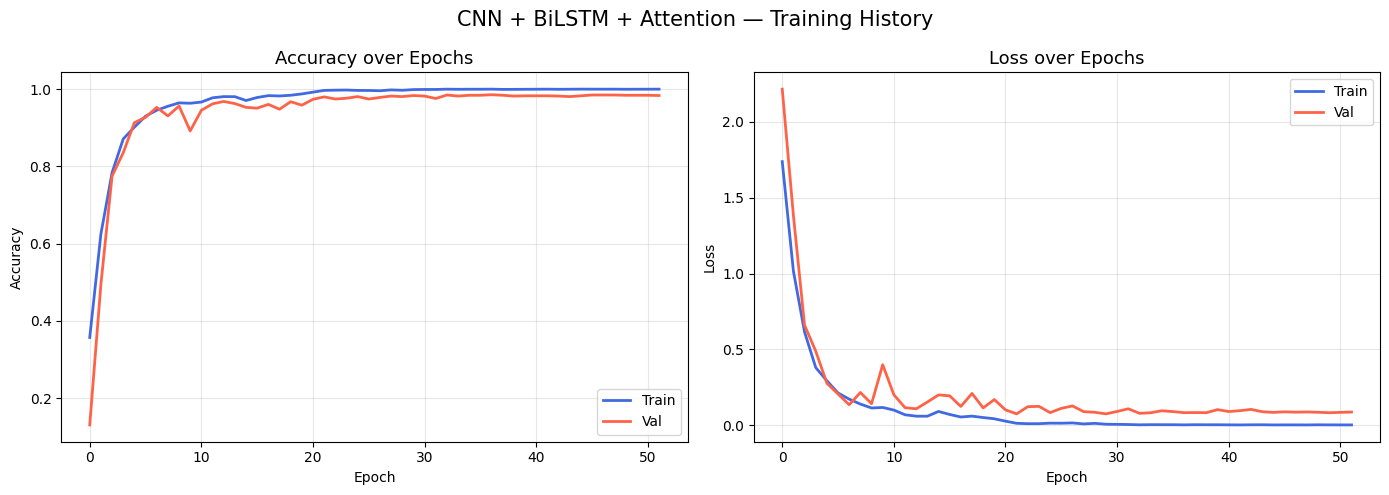

✅ Training curve saved to Drive


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', color='royalblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   color='tomato',    linewidth=2)
axes[0].set_title('Accuracy over Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train', color='royalblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   color='tomato',    linewidth=2)
axes[1].set_title('Loss over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN + BiLSTM + Attention — Training History', fontsize=15)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_history.png', dpi=150)
plt.show()
print('✅ Training curve saved to Drive')

---
## CELL 10 — Evaluate on Test Set

In [ ]:
# Load best saved model
best_model = keras.models.load_model(
    f'{SAVE_DIR}/best_model.keras',
    custom_objects={'AttentionLayer': AttentionLayer}
)

# Predict
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Metrics
test_acc = np.mean(y_pred == y_test)
f1_w     = f1_score(y_test, y_pred, average='weighted')
uar      = f1_score(y_test, y_pred, average='macro')

print('=' * 45)
print('         TEST SET RESULTS')
print('=' * 45)
print(f'  Accuracy (test)  : {test_acc*100:.2f}%')
print(f'  Weighted F1      : {f1_w:.4f}')
print(f'  UAR (macro F1)   : {uar:.4f}')
print('=' * 45)

# Per-class report
target_names = [INT_TO_LABEL[i] for i in range(NUM_CLASSES)]
print('\n── Per-Class Report ──')
print(classification_report(y_test, y_pred, target_names=target_names))

         TEST SET RESULTS
  Accuracy (test)  : 98.82%
  Weighted F1      : 0.9882
  UAR (macro F1)   : 0.9870

── Per-Class Report ──
              precision    recall  f1-score   support

     neutral       0.97      0.97      0.97        96
        calm       0.98      0.99      0.99       192
       happy       0.99      0.99      0.99       192
         sad       0.99      0.98      0.99       192
       angry       0.98      0.99      0.99       192
     fearful       0.98      0.99      0.99       192
     disgust       0.99      0.98      0.99       192
   surprised       1.00      0.99      1.00       192

    accuracy                           0.99      1440
   macro avg       0.99      0.99      0.99      1440
weighted avg       0.99      0.99      0.99      1440



---
## CELL 11 — Confusion Matrix

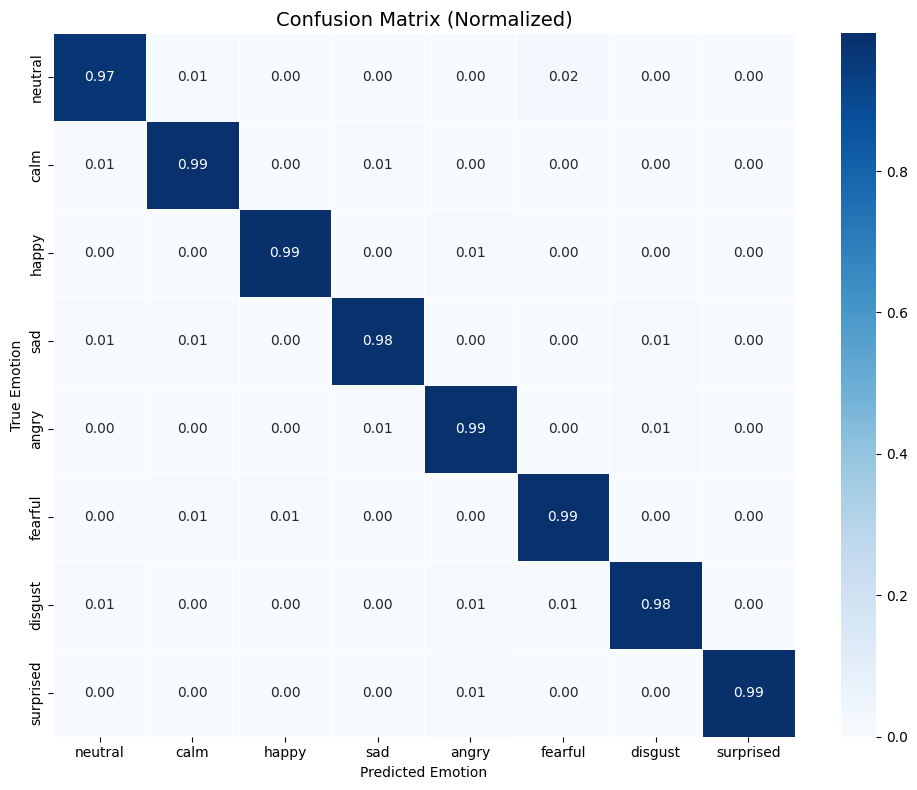

✅ Confusion matrix saved to Drive


In [ ]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalize per row

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot        = True,
    fmt          = '.2f',
    cmap         = 'Blues',
    xticklabels  = target_names,
    yticklabels  = target_names,
    linewidths   = 0.5
)
plt.title('Confusion Matrix (Normalized)', fontsize=14)
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150)
plt.show()
print('✅ Confusion matrix saved to Drive')

---
## CELL 12 — Save Final Model + Files Needed for Streamlit

In [ ]:
# ===============================
# FINAL SAVE (COMPATIBLE VERSION)
# ===============================

# 1. Save FULL model locally (for backup only)
best_model.save("ser_model_full.h5")

# 2. ✅ Save ONLY weights (THIS IS WHAT WE WILL USE IN STREAMLIT)
best_model.save_weights("ser_model.weights.h5")

print('✅ Training complete! Files saved successfully.')
print()
print('=' * 50)
print('   📥 DOWNLOAD THESE FILES')
print('=' * 50)
print('   1. ser_model.weights.h5   ← USE THIS (IMPORTANT)')
print('   2. scaler.pkl')
print('   3. label_map.json')
print('=' * 50)

# ===============================
# DOWNLOAD FILES
# ===============================
from google.colab import files

files.download("ser_model.weights.h5")

✅ Training complete! Files saved successfully.

   📥 DOWNLOAD THESE FILES
   1. ser_model.weights.h5   ← USE THIS (IMPORTANT)
   2. scaler.pkl
   3. label_map.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>